In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load dataset
df = pd.read_csv('../data/online_retail_II.csv', encoding='latin-1')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst look:")
df.head()

Dataset shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First look:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Basic dataset overview
print("=== DATASET OVERVIEW ===")
print(f"Total transactions: {len(df):,}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")

print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\n=== DATA TYPES ===")
print(df.dtypes)

print(f"\n=== TOP 5 COUNTRIES BY TRANSACTIONS ===")
print(df['Country'].value_counts().head())

=== DATASET OVERVIEW ===
Total transactions: 1,067,371
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,942
Unique products: 5,305
Countries: 43

=== MISSING VALUES ===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

=== DATA TYPES ===
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

=== TOP 5 COUNTRIES BY TRANSACTIONS ===
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Name: count, dtype: int64


In [5]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove transactions without Customer ID
df = df.dropna(subset=['Customer ID'])
print(f"After removing missing Customer ID: {len(df):,} transactions")

# Remove cancelled orders (Invoice starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {len(df):,} transactions")

# Remove negative or zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f"After removing invalid quantities/prices: {len(df):,} transactions")

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['Price']

# Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

print(f"\n=== CLEAN DATASET ===")
print(f"Total transactions: {len(df):,}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Total revenue: ${df['TotalPrice'].sum():,.0f}")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

After removing missing Customer ID: 824,364 transactions
After removing cancellations: 805,620 transactions
After removing invalid quantities/prices: 805,549 transactions

=== CLEAN DATASET ===
Total transactions: 805,549
Unique customers: 5,878
Total revenue: $17,743,429
Date range: 2009-12-01 to 2011-12-09


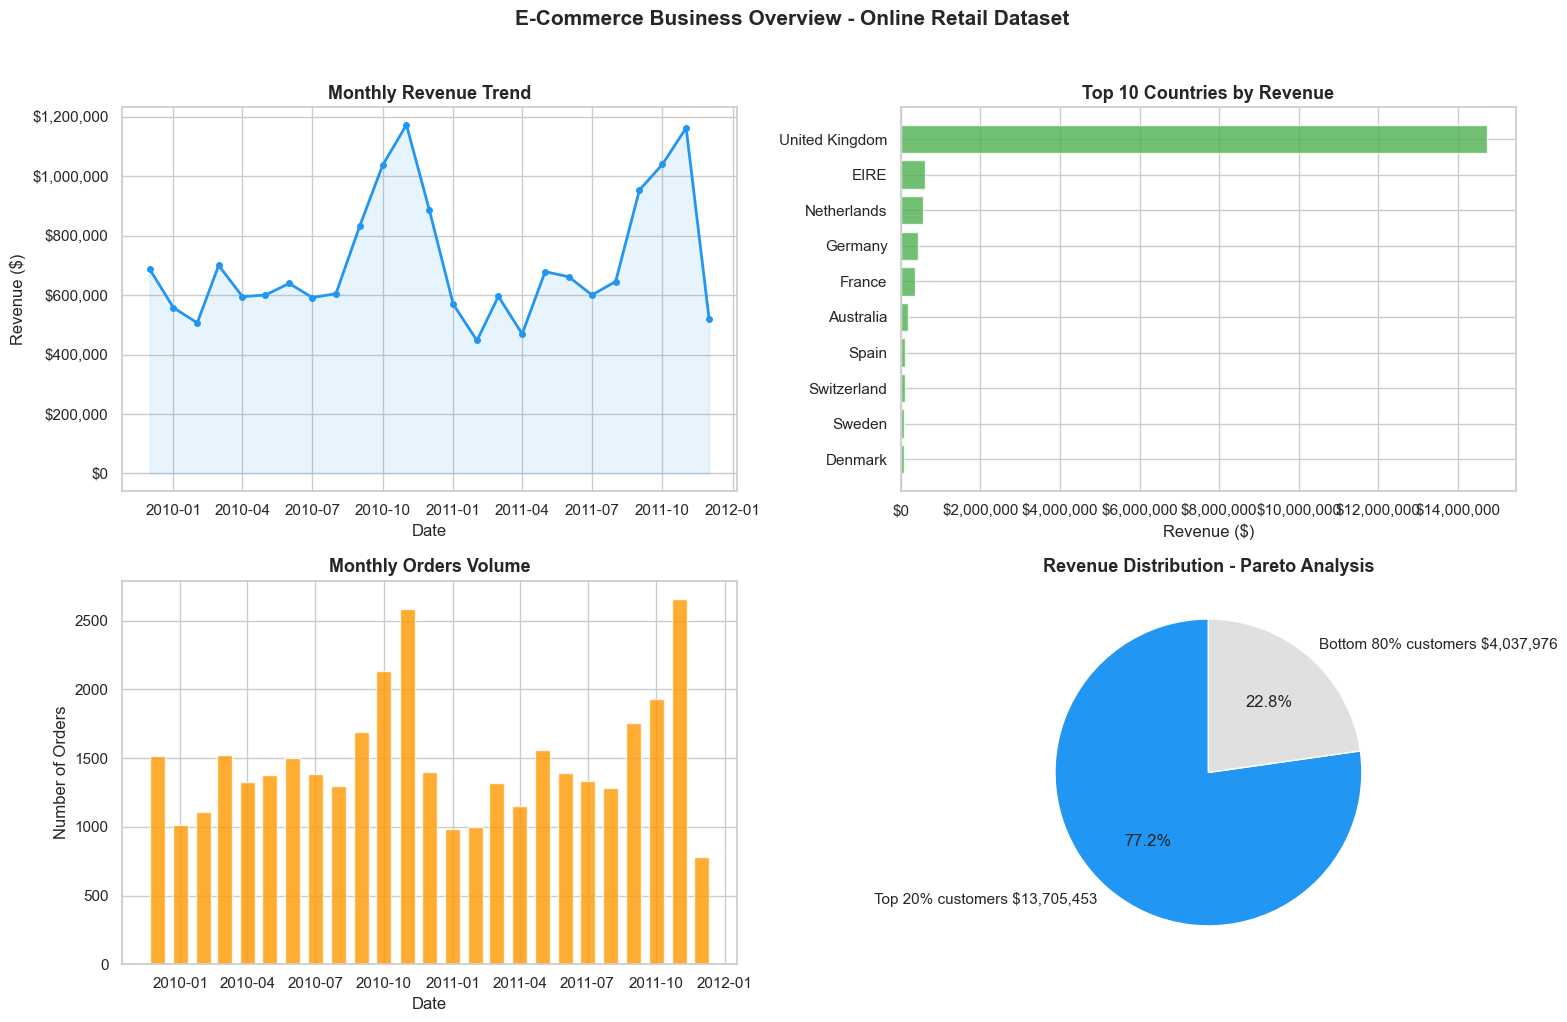

In [6]:
# Monthly revenue trend
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Monthly revenue trend
axes[0,0].plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'],
               color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[0,0].fill_between(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'],
                        alpha=0.1, color='#2196F3')
axes[0,0].set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 2. Revenue by country top 10
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[0,1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#4CAF50', alpha=0.8)
axes[0,1].set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Revenue ($)')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 3. Orders per month
monthly_orders = df.groupby('YearMonth')['Invoice'].nunique().reset_index()
monthly_orders['YearMonth'] = monthly_orders['YearMonth'].dt.to_timestamp()
axes[1,0].bar(monthly_orders['YearMonth'], monthly_orders['Invoice'],
              color='#FF9800', alpha=0.8, width=20)
axes[1,0].set_title('Monthly Orders Volume', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Number of Orders')

# 4. Pareto analysis
customer_revenue = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
top_20_pct = int(len(customer_revenue) * 0.2)
top_revenue = customer_revenue.iloc[:top_20_pct].sum()
rest_revenue = customer_revenue.iloc[top_20_pct:].sum()
top_label = f'Top 20% customers ${top_revenue:,.0f}'
rest_label = f'Bottom 80% customers ${rest_revenue:,.0f}'
axes[1,1].pie([top_revenue, rest_revenue],
              labels=[top_label, rest_label],
              colors=['#2196F3', '#E0E0E0'],
              autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Revenue Distribution - Pareto Analysis', fontsize=13, fontweight='bold')

plt.suptitle('E-Commerce Business Overview - Online Retail Dataset',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../img/business_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Define reference date for recency calculation
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# Calculate RFM metrics per customer
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"\n=== RFM SUMMARY ===")
print(rfm.describe().round(2))

print(f"\n=== RFM SAMPLE (Top 10 by Monetary) ===")
print(rfm.sort_values('Monetary', ascending=False).head(10).to_string(index=False))

Reference date: 2011-12-10

=== RFM SUMMARY ===
       Customer ID  Recency  Frequency   Monetary
count      5878.00  5878.00    5878.00    5878.00
mean      15315.31   201.33       6.29    3018.62
std        1715.57   209.34      13.01   14737.73
min       12346.00     1.00       1.00       2.95
25%       13833.25    26.00       1.00     348.76
50%       15314.50    96.00       3.00     898.92
75%       16797.75   380.00       7.00    2307.09
max       18287.00   739.00     398.00  608821.65

=== RFM SAMPLE (Top 10 by Monetary) ===
 Customer ID  Recency  Frequency  Monetary
       18102        1        145 608821.65
       14646        2        151 528602.52
       14156       10        156 313946.37
       14911        1        398 295972.63
       17450        8         51 246973.09
       13694        4        143 196482.81
       17511        3         60 175603.55
       16446        1          2 168472.50
       16684        4         55 147142.77
       12415       24         2

In [8]:
# Assign RFM scores 1-5
# Recency: lower is better (recent = high score)
# Frequency and Monetary: higher is better

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Create RFM combined score
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Define customer segments based on RFM scores
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Segment summary
print("=== CUSTOMER SEGMENTS ===")
segment_summary = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2)
segment_summary['Revenue_%'] = (segment_summary['Total_Revenue'] / 
                                  rfm['Monetary'].sum() * 100).round(1)
print(segment_summary.sort_values('Total_Revenue', ascending=False))

=== CUSTOMER SEGMENTS ===
                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                    
Champions                 1300        19.97          17.09       9329.32   
Loyal Customers           1134        73.39           5.93       2295.58   
At Risk                    615       359.53           5.62       2517.23   
Need Attention            1517       343.30           1.61        446.84   
New Customers              443        28.11           1.46        890.83   
Potential Loyalists        356        79.77           2.73        602.15   
Lost                       513       568.23           1.00        345.37   

                     Total_Revenue  Revenue_%  
Segment                                        
Champions              12128115.56       68.4  
Loyal Customers         2603183.47       14.7  
At Risk                 1548098.81        8.7  
Need Attention           677849.09        3.8  
N

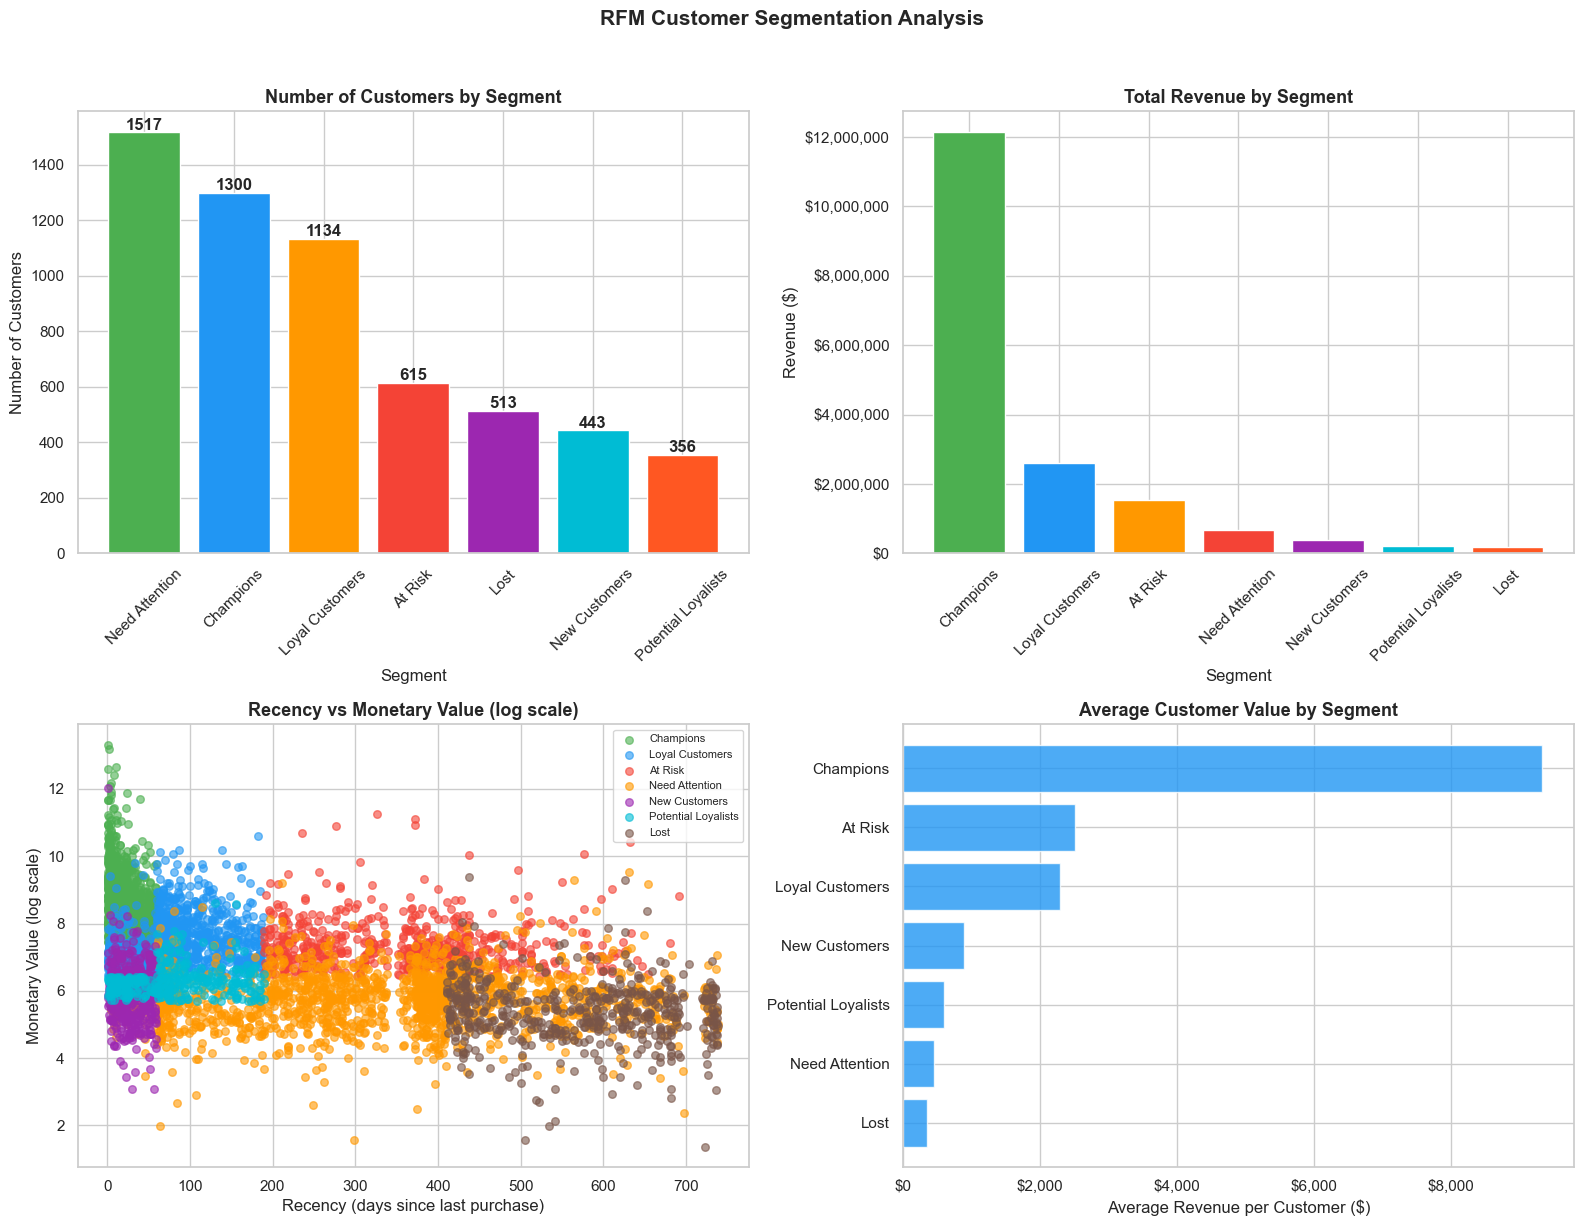

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Customers by segment
segment_counts = rfm['Segment'].value_counts()
colors = ['#4CAF50','#2196F3','#FF9800','#F44336','#9C27B0','#00BCD4','#FF5722','#795548']
axes[0,0].bar(segment_counts.index, segment_counts.values, color=colors[:len(segment_counts)])
axes[0,0].set_title('Number of Customers by Segment', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Segment')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(segment_counts.values):
    axes[0,0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 2. Revenue by segment
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[0,1].bar(revenue_by_segment.index, revenue_by_segment.values, color=colors[:len(revenue_by_segment)])
axes[0,1].set_title('Total Revenue by Segment', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Revenue ($)')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0,1].tick_params(axis='x', rotation=45)

# 3. RFM scatter plot - Recency vs Monetary
scatter_colors = {
    'Champions': '#4CAF50',
    'Loyal Customers': '#2196F3', 
    'At Risk': '#F44336',
    'Need Attention': '#FF9800',
    'New Customers': '#9C27B0',
    'Potential Loyalists': '#00BCD4',
    'Lost': '#795548',
    'Cant Lose Them': '#FF5722'
}

for segment, color in scatter_colors.items():
    mask = rfm['Segment'] == segment
    if mask.sum() > 0:
        axes[1,0].scatter(rfm[mask]['Recency'], 
                          np.log1p(rfm[mask]['Monetary']),
                          c=color, label=segment, alpha=0.6, s=30)

axes[1,0].set_title('Recency vs Monetary Value (log scale)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Recency (days since last purchase)')
axes[1,0].set_ylabel('Monetary Value (log scale)')
axes[1,0].legend(fontsize=8, loc='upper right')

# 4. Average monetary by segment
avg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1,1].barh(avg_monetary.index[::-1], avg_monetary.values[::-1], color='#2196F3', alpha=0.8)
axes[1,1].set_title('Average Customer Value by Segment', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Average Revenue per Customer ($)')
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.suptitle('RFM Customer Segmentation Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../img/rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

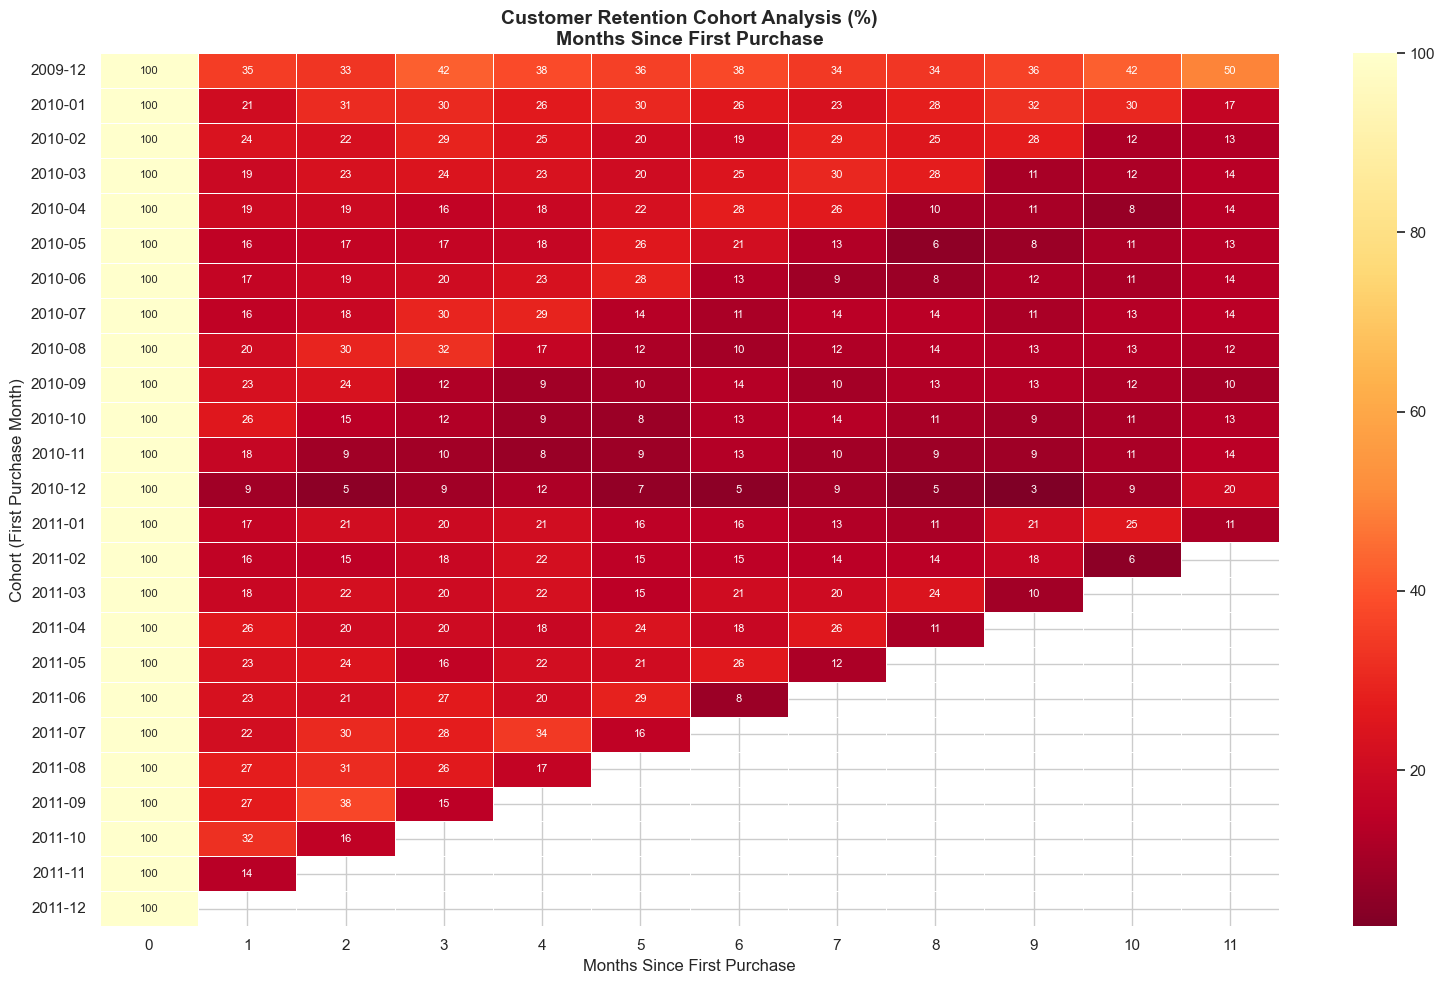

=== AVERAGE RETENTION RATE BY MONTH ===
Month 1: 21.2%
Month 2: 21.9%
Month 3: 21.6%
Month 4: 20.5%
Month 5: 18.8%
Month 6: 17.8%
Month 7: 17.6%
Month 8: 15.6%
Month 9: 15.3%
Month 10: 15.0%
Month 11: 16.4%
Month 12: 18.2%


In [10]:
# Cohort Analysis
# Get first purchase date per customer
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

# Calculate cohort index (months since first purchase)
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Count unique customers per cohort and period
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', 
                                        columns='CohortIndex', 
                                        values='Customer ID')

# Calculate retention rates
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Plot retention heatmap - first 12 months only
plt.figure(figsize=(16, 10))
retention_12 = retention_matrix.iloc[:, :12]
sns.heatmap(retention_12, 
            annot=True, fmt='.0f',
            cmap='YlOrRd_r',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Customer Retention Cohort Analysis (%)\nMonths Since First Purchase',
          fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('../img/cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Average retention by month
avg_retention = retention_matrix.iloc[:, 1:13].mean()
print("=== AVERAGE RETENTION RATE BY MONTH ===")
for month, rate in avg_retention.items():
    print(f"Month {month}: {rate:.1f}%")

In [11]:
# Calculate Customer Lifetime Value
# CLV = Average Order Value x Purchase Frequency x Customer Lifespan

# Customer metrics
customer_metrics = df.groupby('Customer ID').agg(
    TotalRevenue=('TotalPrice', 'sum'),
    TotalOrders=('Invoice', 'nunique'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

# Average order value
customer_metrics['AvgOrderValue'] = customer_metrics['TotalRevenue'] / customer_metrics['TotalOrders']

# Customer lifespan in months
customer_metrics['LifespanMonths'] = (
    (customer_metrics['LastPurchase'] - customer_metrics['FirstPurchase']).dt.days / 30
).clip(lower=1)

# Purchase frequency per month
customer_metrics['FrequencyPerMonth'] = (
    customer_metrics['TotalOrders'] / customer_metrics['LifespanMonths']
)

# CLV = AOV x Frequency per month x 12 months projection
customer_metrics['CLV_12months'] = (
    customer_metrics['AvgOrderValue'] * 
    customer_metrics['FrequencyPerMonth'] * 12
)

# Merge with RFM segments
clv_rfm = customer_metrics.merge(rfm[['Customer ID', 'Segment', 'RFM_Score']], 
                                   on='Customer ID')

# CLV by segment
print("=== CLV BY SEGMENT ===")
clv_summary = clv_rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_CLV=('CLV_12months', 'mean'),
    Median_CLV=('CLV_12months', 'median'),
    Total_CLV=('CLV_12months', 'sum')
).round(2).sort_values('Avg_CLV', ascending=False)
print(clv_summary)

print(f"\n=== OVERALL CLV METRICS ===")
print(f"Average CLV (12 months): ${clv_rfm['CLV_12months'].mean():,.0f}")
print(f"Median CLV (12 months): ${clv_rfm['CLV_12months'].median():,.0f}")
print(f"Total projected revenue (12 months): ${clv_rfm['CLV_12months'].sum():,.0f}")

=== CLV BY SEGMENT ===
                     Customers  Avg_CLV  Median_CLV   Total_CLV
Segment                                                        
Champions                 1300  6167.97     2877.97  8018361.88
At Risk                    615  5024.68     2176.74  3090179.66
New Customers              443  4624.83     2501.52  2048798.05
Lost                       513  4144.49     2569.56  2126124.02
Need Attention            1517  3764.56     2178.00  5710832.10
Loyal Customers           1134  3339.51     1489.59  3787006.55
Potential Loyalists        356  2214.81      855.85   788473.59

=== OVERALL CLV METRICS ===
Average CLV (12 months): $4,350
Median CLV (12 months): $2,208
Total projected revenue (12 months): $25,569,776


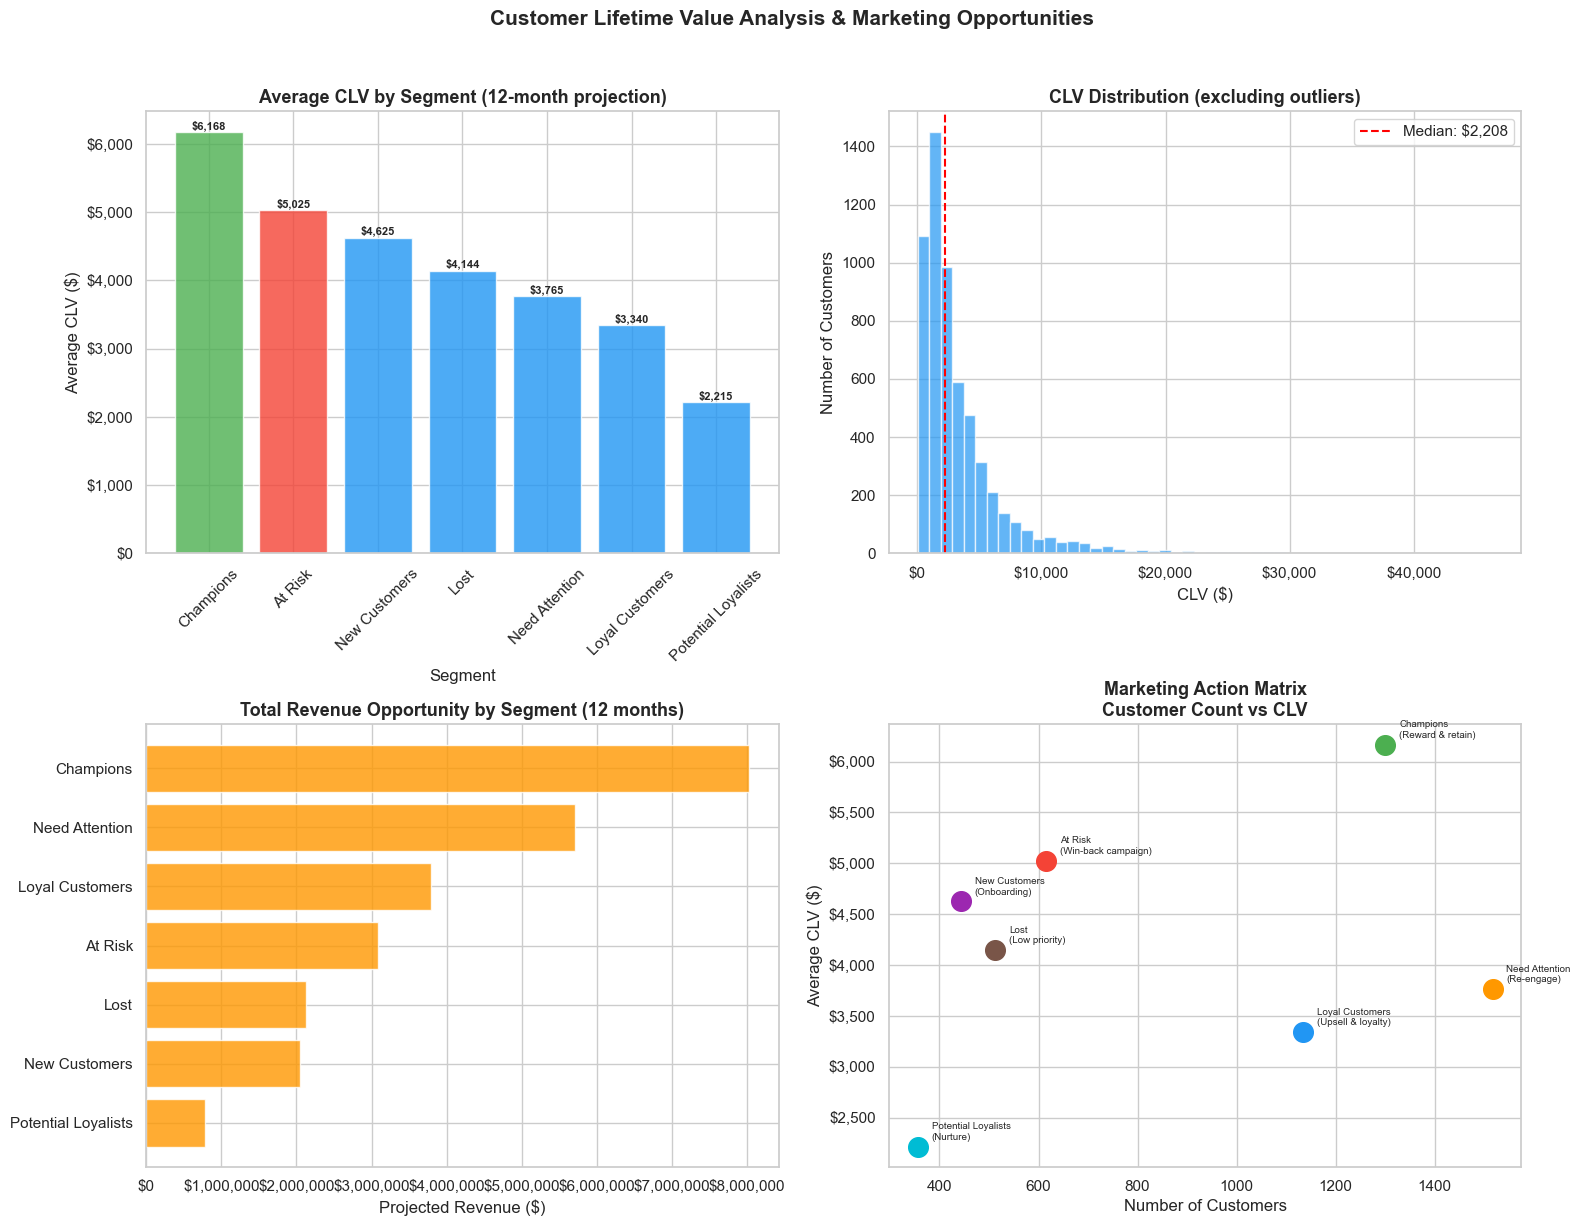

=== MARKETING RECOMMENDATIONS ===
Champions (1300 customers): Reward & retain — they generate 68.4% of revenue
At Risk (615 customers): Win-back campaign — avg CLV $5,025
New Customers (443 customers): Onboarding — convert to Loyal Customers
Need Attention (1517 customers): Re-engagement — largest segment by count


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. CLV by segment
clv_by_segment = clv_rfm.groupby('Segment')['CLV_12months'].mean().sort_values(ascending=False)
bars = axes[0,0].bar(clv_by_segment.index, clv_by_segment.values, 
                      color=['#4CAF50' if s == 'Champions' else 
                             '#F44336' if s == 'At Risk' else '#2196F3' 
                             for s in clv_by_segment.index], alpha=0.8)
axes[0,0].set_title('Average CLV by Segment (12-month projection)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Segment')
axes[0,0].set_ylabel('Average CLV ($)')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0,0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, clv_by_segment.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                   f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')

# 2. CLV distribution
axes[0,1].hist(clv_rfm[clv_rfm['CLV_12months'] < 50000]['CLV_12months'], 
               bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0,1].set_title('CLV Distribution (excluding outliers)', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('CLV ($)')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0,1].axvline(clv_rfm['CLV_12months'].median(), color='red', 
                   linestyle='--', label=f'Median: ${clv_rfm["CLV_12months"].median():,.0f}')
axes[0,1].legend()

# 3. Segment revenue opportunity
segment_opportunity = clv_rfm.groupby('Segment')['CLV_12months'].sum().sort_values(ascending=False)
axes[1,0].barh(segment_opportunity.index[::-1], segment_opportunity.values[::-1], 
               color='#FF9800', alpha=0.8)
axes[1,0].set_title('Total Revenue Opportunity by Segment (12 months)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Projected Revenue ($)')
axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 4. Marketing action matrix
segments = ['Champions', 'Loyal Customers', 'At Risk', 'Need Attention', 
            'New Customers', 'Potential Loyalists', 'Lost']
actions = ['Reward & retain', 'Upsell & loyalty', 'Win-back campaign', 
           'Re-engage', 'Onboarding', 'Nurture', 'Low priority']
clv_vals = [clv_summary.loc[s, 'Avg_CLV'] if s in clv_summary.index else 0 for s in segments]
customer_counts = [clv_summary.loc[s, 'Customers'] if s in clv_summary.index else 0 for s in segments]

scatter_colors_map = ['#4CAF50','#2196F3','#F44336','#FF9800','#9C27B0','#00BCD4','#795548']
for i, (seg, action, clv_v, count, color) in enumerate(
        zip(segments, actions, clv_vals, customer_counts, scatter_colors_map)):
    axes[1,1].scatter(count, clv_v, s=200, c=color, zorder=5)
    axes[1,1].annotate(f'{seg}\n({action})', (count, clv_v), 
                        textcoords='offset points', xytext=(10, 5), fontsize=7)

axes[1,1].set_title('Marketing Action Matrix\nCustomer Count vs CLV', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Number of Customers')
axes[1,1].set_ylabel('Average CLV ($)')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.suptitle('Customer Lifetime Value Analysis & Marketing Opportunities',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../img/clv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== MARKETING RECOMMENDATIONS ===")
print(f"Champions ({clv_summary.loc['Champions','Customers']:.0f} customers): Reward & retain — they generate 68.4% of revenue")
print(f"At Risk ({clv_summary.loc['At Risk','Customers']:.0f} customers): Win-back campaign — avg CLV ${clv_summary.loc['At Risk','Avg_CLV']:,.0f}")
print(f"New Customers ({clv_summary.loc['New Customers','Customers']:.0f} customers): Onboarding — convert to Loyal Customers")
print(f"Need Attention ({clv_summary.loc['Need Attention','Customers']:.0f} customers): Re-engagement — largest segment by count")

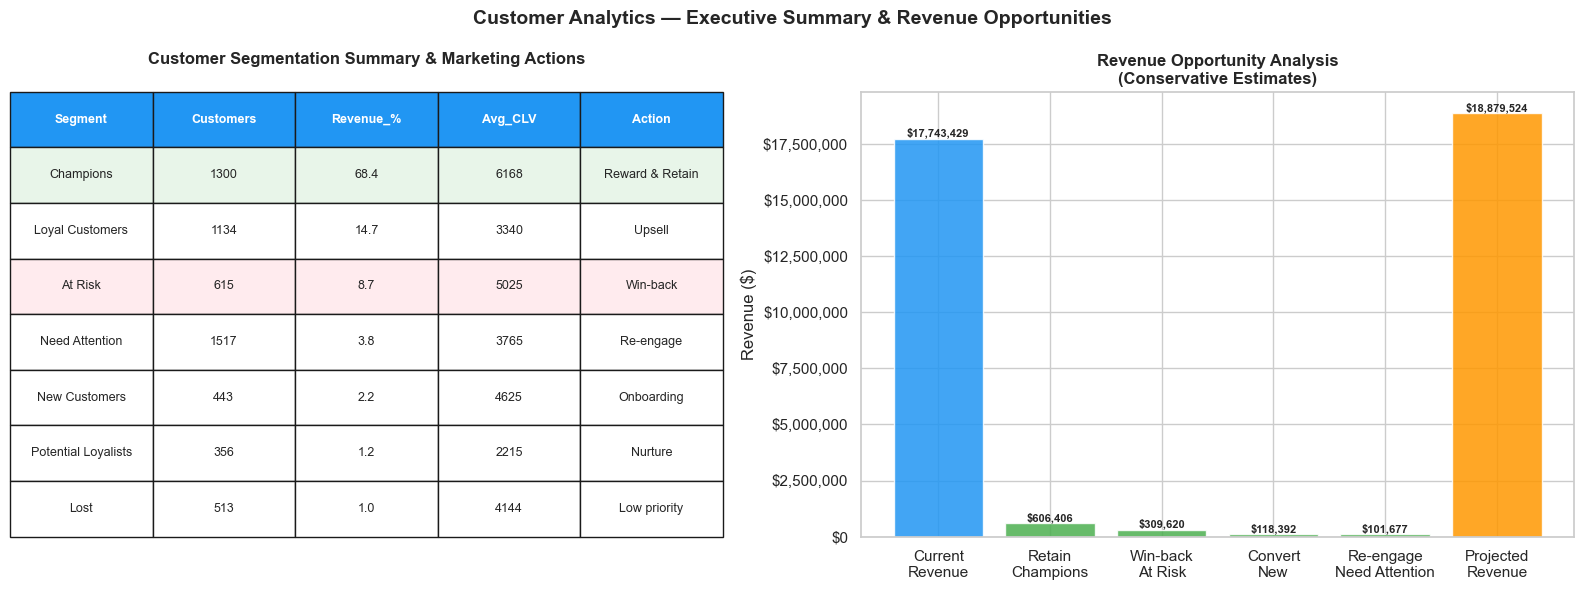

=== PROJECT COMPLETE ===
Total customers analyzed: 5,878
Total historical revenue: $17,743,429
Champions (22% of customers): 68.4% of revenue
At Risk customers: 615 — avg CLV $5,025 — win-back opportunity: $309K
Projected revenue (12 months): $25,569,776


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Segment summary table visual
segments_data = {
    'Segment': ['Champions', 'Loyal Customers', 'At Risk', 
                'Need Attention', 'New Customers', 'Potential Loyalists', 'Lost'],
    'Customers': [1300, 1134, 615, 1517, 443, 356, 513],
    'Revenue_%': [68.4, 14.7, 8.7, 3.8, 2.2, 1.2, 1.0],
    'Avg_CLV': [6168, 3340, 5025, 3765, 4625, 2215, 4144],
    'Action': ['Reward & Retain', 'Upsell', 'Win-back', 
               'Re-engage', 'Onboarding', 'Nurture', 'Low priority']
}
summary_df = pd.DataFrame(segments_data)

axes[0].axis('off')
table = axes[0].table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Color header
for j in range(len(summary_df.columns)):
    table[0, j].set_facecolor('#2196F3')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color Champions row
for j in range(len(summary_df.columns)):
    table[1, j].set_facecolor('#E8F5E9')

# Color At Risk row
for j in range(len(summary_df.columns)):
    table[3, j].set_facecolor('#FFEBEE')

axes[0].set_title('Customer Segmentation Summary & Marketing Actions',
                   fontsize=12, fontweight='bold', pad=20)

# 2. Revenue opportunity waterfall
categories = ['Current\nRevenue', 'Retain\nChampions', 'Win-back\nAt Risk',
              'Convert\nNew', 'Re-engage\nNeed Attention', 'Projected\nRevenue']
values = [17743429, 12128116 * 0.05, 1548099 * 0.20, 
          394639 * 0.30, 677849 * 0.15, 0]
values[-1] = sum(values[:-1])

colors_wf = ['#2196F3', '#4CAF50', '#4CAF50', '#4CAF50', '#4CAF50', '#FF9800']
axes[1].bar(categories, values, color=colors_wf, alpha=0.85)
axes[1].set_title('Revenue Opportunity Analysis\n(Conservative Estimates)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for i, v in enumerate(values):
    axes[1].text(i, v + 100000, f'${v:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Customer Analytics — Executive Summary & Revenue Opportunities',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== PROJECT COMPLETE ===")
print(f"Total customers analyzed: 5,878")
print(f"Total historical revenue: $17,743,429")
print(f"Champions (22% of customers): 68.4% of revenue")
print(f"At Risk customers: 615 — avg CLV $5,025 — win-back opportunity: $309K")
print(f"Projected revenue (12 months): $25,569,776")

In [14]:
# Export RFM segments
rfm_export = rfm[['Customer ID', 'Recency', 'Frequency', 
                   'Monetary', 'R_Score', 'F_Score', 
                   'M_Score', 'RFM_Score', 'Segment']]
rfm_export.to_csv('../data/rfm_segments.csv', index=False)
print(f"RFM exported: {len(rfm_export):,} rows")

# Export CLV by customer
clv_export = clv_rfm[['Customer ID', 'TotalRevenue', 'TotalOrders',
                       'AvgOrderValue', 'LifespanMonths',
                       'FrequencyPerMonth', 'CLV_12months', 'Segment']]
clv_export.to_csv('../data/clv_customers.csv', index=False)
print(f"CLV exported: {len(clv_export):,} rows")

RFM exported: 5,878 rows
CLV exported: 5,878 rows
